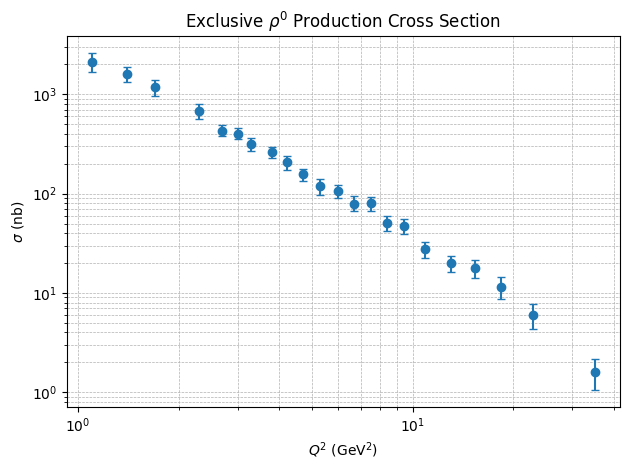

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA
# -----------------------------
# replace with your actual filename
file_path = "Table9.csv"
df = pd.read_csv(file_path, comment="#", sep=",", engine="python")

# -----------------------------
# EXTRACT COLUMNS
# -----------------------------
Q2 = df["Q**2 [GEV**2]"].values
sigma = df["SIG [NB]"].values

# statistical uncertainties
stat_plus = df["stat +"].values
stat_minus = np.abs(df["stat -"].values)

# systematic uncertainties
sys_plus = df["sys +"].values
sys_minus = np.abs(df["sys -"].values)

# -----------------------------
# COMBINE ERRORS (quadrature)
# -----------------------------
err_plus = np.sqrt(stat_plus**2 + sys_plus**2)
err_minus = np.sqrt(stat_minus**2 + sys_minus**2)

# -----------------------------
# PLOT
# -----------------------------
plt.figure()

plt.errorbar(
    Q2,
    sigma,
    yerr=[err_minus, err_plus],
    fmt='o',
    capsize=3
)

plt.xlabel(r"$Q^2$ (GeV$^2$)")
plt.ylabel(r"$\sigma$ (nb)")
plt.title(r"Exclusive $\rho^0$ Production Cross Section")

# HEP-style: log scales (important!)
plt.xscale("log")
plt.yscale("log")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

In [3]:
# -----------------------------
# CURVE OF BEST FIT (POWER LAW)
# -----------------------------
mask = (Q2 > 0) & (sigma > 0)

log_Q2 = np.log(Q2[mask])
log_sigma = np.log(sigma[mask])

coeffs = np.polyfit(log_Q2, log_sigma, 1)

n = coeffs[0]          # slope
logA = coeffs[1]       # intercept
A = np.exp(logA)

print("Fit parameters:")
print("A =", A)
print("n =", n)

Fit parameters:
A = 3478.5795028082343
n = -2.0065853406853353


Best-fit parameters:
A = 3478.5795028082343
n = -2.0065853406853353


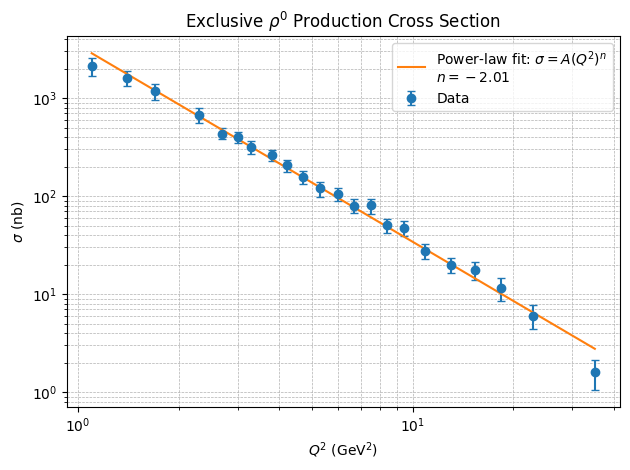

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA
# -----------------------------
file_path = "Table9.csv"

df = pd.read_csv(
    file_path,
    comment="#",
    sep=",",
    engine="python"
)

# -----------------------------
# EXTRACT COLUMNS
# -----------------------------
Q2 = df["Q**2 [GEV**2]"].values
sigma = df["SIG [NB]"].values

# statistical uncertainties
stat_plus = df["stat +"].values
stat_minus = np.abs(df["stat -"].values)

# systematic uncertainties
sys_plus = df["sys +"].values
sys_minus = np.abs(df["sys -"].values)

# -----------------------------
# COMBINE ERRORS (quadrature)
# -----------------------------
err_plus = np.sqrt(stat_plus**2 + sys_plus**2)
err_minus = np.sqrt(stat_minus**2 + sys_minus**2)

# symmetric error for fitting
sigma_err = (err_plus + err_minus) / 2

# -----------------------------
# POWER-LAW FIT (log-log)
# σ = A * (Q^2)^n
# -----------------------------
mask = (Q2 > 0) & (sigma > 0)

log_Q2 = np.log(Q2[mask])
log_sigma = np.log(sigma[mask])

coeffs = np.polyfit(log_Q2, log_sigma, 1)

n = coeffs[0]
logA = coeffs[1]
A = np.exp(logA)

print("Best-fit parameters:")
print("A =", A)
print("n =", n)

# -----------------------------
# SMOOTH FIT CURVE
# -----------------------------
Q2_fit = np.linspace(min(Q2), max(Q2), 300)
sigma_fit = A * Q2_fit**n

# -----------------------------
# PLOT
# -----------------------------
plt.figure()

# data with error bars
plt.errorbar(
    Q2,
    sigma,
    yerr=[err_minus, err_plus],
    fmt='o',
    capsize=3,
    label="Data"
)

# best fit curve
plt.plot(
    Q2_fit,
    sigma_fit,
    '-',
    label=f"Power-law fit: $\\sigma = A (Q^2)^n$\n$n = {n:.2f}$"
)

plt.xlabel(r"$Q^2$ (GeV$^2$)")
plt.ylabel(r"$\sigma$ (nb)")
plt.title(r"Exclusive $\rho^0$ Production Cross Section")

# log-log (standard in HEP)
plt.xscale("log")
plt.yscale("log")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()

plt.tight_layout()
plt.show()

Fitted rho parameters:
A = 7059.51703322683
n = 2.218922024634209

Example significance values:
[9.27372125 9.27274687 9.27147501 9.26990228 9.26802538]


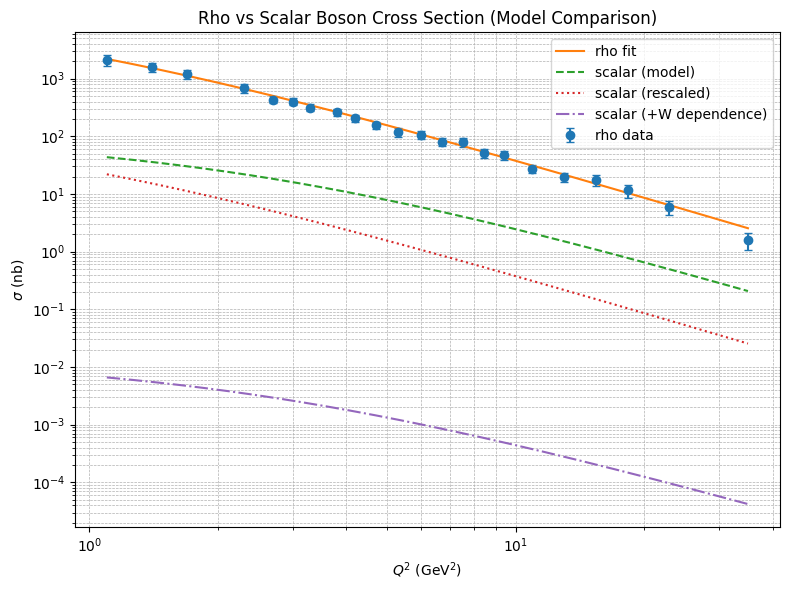

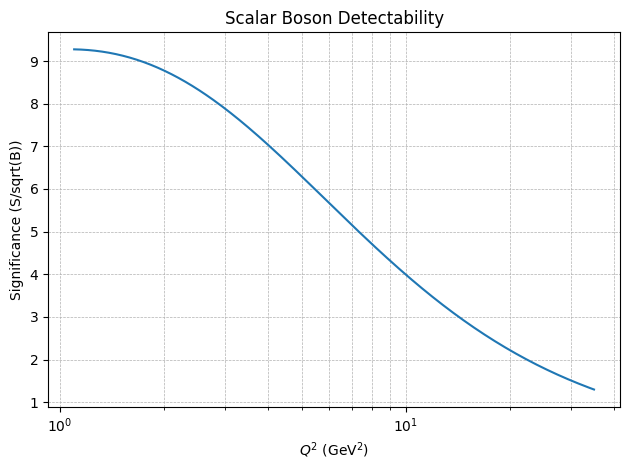

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# LOAD DATA
# -----------------------------
file_path = "Table9.csv"
df = pd.read_csv(file_path, comment="#", sep=",", engine="python")

# -----------------------------
# EXTRACT COLUMNS
# -----------------------------
Q2 = df["Q**2 [GEV**2]"].values
sigma_rho = df["SIG [NB]"].values

# uncertainties
stat_plus = df["stat +"].values
stat_minus = np.abs(df["stat -"].values)
sys_plus = df["sys +"].values
sys_minus = np.abs(df["sys -"].values)

# combine uncertainties
err_plus = np.sqrt(stat_plus**2 + sys_plus**2)
err_minus = np.sqrt(stat_minus**2 + sys_minus**2)

# -----------------------------
# FIT RHO CROSS SECTION
# Model: sigma = A / (Q2 + m^2)^n
# -----------------------------
def rho_model(Q2, A, n):
    m_rho = 0.77  # GeV
    return A / (Q2 + m_rho**2)**n

popt, pcov = curve_fit(rho_model, Q2, sigma_rho, maxfev=10000)
A_fit, n_fit = popt

print("Fitted rho parameters:")
print("A =", A_fit)
print("n =", n_fit)

# smooth curve
Q2_fit = np.logspace(np.log10(min(Q2)), np.log10(max(Q2)), 300)
sigma_rho_fit = rho_model(Q2_fit, A_fit, n_fit)

# -----------------------------
# DEFINE SCALAR BOSON MODEL
# -----------------------------
def sigma_scalar(Q2, g=0.3, m_phi=1.5, n=n_fit, A=A_fit):
    return A * g**2 / (Q2 + m_phi**2)**n

sigma_phi = sigma_scalar(Q2_fit)

# -----------------------------
# RESCALE FROM RHO (ALT MODEL)
# -----------------------------
def rescale_from_rho(sigma_rho, g_ratio=0.1, mass_ratio=1.0):
    return sigma_rho * g_ratio**2 * mass_ratio

sigma_phi_rescaled = rescale_from_rho(sigma_rho_fit)

# -----------------------------
# SIMPLE KINEMATICS (W)
# -----------------------------
Mp = 0.938  # proton mass (GeV)
W = np.sqrt(Q2_fit + Mp**2)

def sigma_scalar_with_W(Q2, W, g=0.3, m_phi=1.5, n=n_fit):
    return g**2 * W**0.2 / (Q2 + m_phi**2)**n

sigma_phi_W = sigma_scalar_with_W(Q2_fit, W)

# -----------------------------
# EVENT YIELD + SIGNIFICANCE
# -----------------------------
luminosity = 100  # inverse nb

N_phi = luminosity * sigma_phi
N_rho = luminosity * sigma_rho_fit

significance = N_phi / np.sqrt(N_rho)

print("\nExample significance values:")
print(significance[:5])

# -----------------------------
# PLOT RESULTS
# -----------------------------
plt.figure(figsize=(8,6))

# data
plt.errorbar(
    Q2,
    sigma_rho,
    yerr=[err_minus, err_plus],
    fmt='o',
    capsize=3,
    label="rho data"
)

# fitted rho
plt.plot(Q2_fit, sigma_rho_fit, label="rho fit")

# scalar predictions
plt.plot(Q2_fit, sigma_phi, linestyle="--", label="scalar (model)")
plt.plot(Q2_fit, sigma_phi_rescaled, linestyle=":", label="scalar (rescaled)")
plt.plot(Q2_fit, sigma_phi_W, linestyle="-.", label="scalar (+W dependence)")

# scales
plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$Q^2$ (GeV$^2$)")
plt.ylabel(r"$\sigma$ (nb)")
plt.title("Rho vs Scalar Boson Cross Section (Model Comparison)")

plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

# -----------------------------
# SIGNIFICANCE PLOT
# -----------------------------
plt.figure()

plt.plot(Q2_fit, significance)

plt.xscale("log")
plt.xlabel(r"$Q^2$ (GeV$^2$)")
plt.ylabel("Significance (S/sqrt(B))")
plt.title("Scalar Boson Detectability")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()